<a href="https://colab.research.google.com/github/fahmiprasetiyo/data-science-2026/blob/main/Pertemuan13_FahmiPrasetiyoHadiatna_240401020107_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Pertemuan 13: Pengantar Topik Lanjutan: Deep Learning & NLP Dasar
* Fahmi Prasetiyo Hadiatna
* 240401020107
* IF-403

###1: Generate & Eksplorasi Dataset Non-Linear

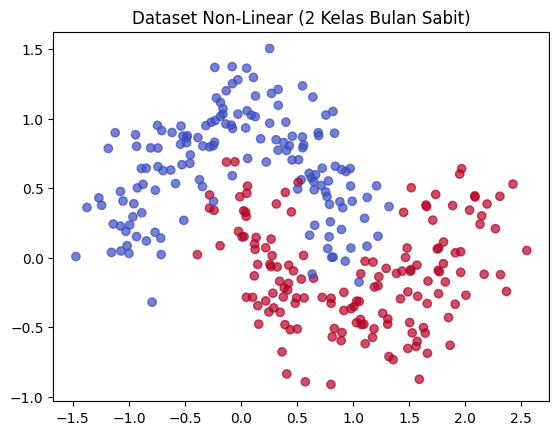

In [1]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
X, y = make_moons(n_samples=300, noise=0.2, random_state=42)
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', alpha=0.7)
plt.title('Dataset Non-Linear (2 Kelas Bulan Sabit)')
plt.show()
# Perhatikan: kedua kelas saling melengkung dan bertautan,
# sehingga tidak mungkin dipisahkan dengan satu garis lurus.

###2: Bangun & Latih Neural Network Sederhana

In [2]:
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
X_tr, X_te, y_tr, y_te = train_test_split(
X, y, test_size=0.2, random_state=42)
model = Sequential([
Dense(16, activation='relu', input_shape=(2,)),
Dense(8, activation='relu'),
Dense(1, activation='sigmoid')
])
model.compile(optimizer='adam', loss='binary_crossentropy',
metrics=['accuracy'])
model.summary()
history = model.fit(X_tr, y_tr, epochs=30,
validation_split=0.2, verbose=0)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │            48 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 193 (772.00 B)

 Trainable params: 193 (772.00 B)

 Non-trainable params: 0 (0.00 B)

###3: Evaluasi & Visualisasi Kurva Belajar

Akurasi pada data uji: 0.900


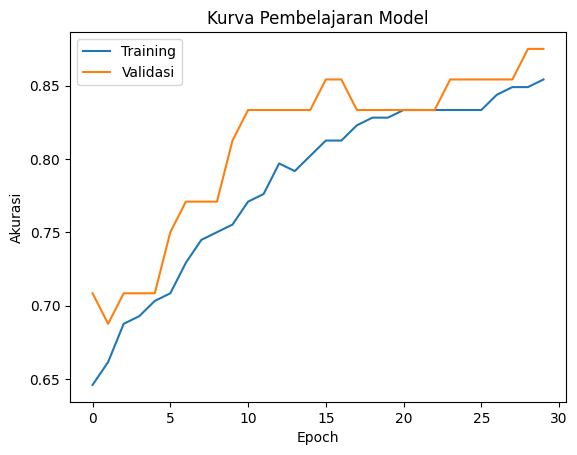

In [3]:
loss, acc = model.evaluate(X_te, y_te, verbose=0)
print(f'Akurasi pada data uji: {acc:.3f}')
plt.plot(history.history['accuracy'], label='Training')
plt.plot(history.history['val_accuracy'], label='Validasi')
plt.xlabel('Epoch'); plt.ylabel('Akurasi')
plt.legend(); plt.title('Kurva Pembelajaran Model')
plt.show()
# Interpretasikan dalam sel Markdown:
# Apakah akurasi training & validasi saling mendekat (baik),
# atau saling menjauh (indikasi overfitting)?

###4: Siapkan Dataset Ulasan Produk

In [4]:
ulasan = [
'Barangnya bagus banget, pengiriman cepat',
'Kualitas jelek, tidak sesuai deskripsi',
'Sangat puas, akan beli lagi',
'Kecewa, barang rusak saat sampai',
'Recommended, harga sesuai kualitas',
'Buruk sekali, tidak sesuai ekspektasi',
# ... tambahkan hingga 40 ulasan
]
label = [1, 0, 1, 0, 1, 0] # 1 = positif, 0 = negatif

###5: Ubah Teks Menjadi TF-IDF

In [5]:
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf = TfidfVectorizer()
X_text = tfidf.fit_transform(ulasan)
print('Jumlah kata unik:', len(tfidf.get_feature_names_out()))
print(tfidf.get_feature_names_out()[:10])

Jumlah kata unik: 25
['akan' 'bagus' 'banget' 'barang' 'barangnya' 'beli' 'buruk' 'cepat'
 'deskripsi' 'ekspektasi']


###6: Latih Model Klasifikasi Sentimen & Evaluasi

In [6]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
Xt_tr, Xt_te, yt_tr, yt_te = train_test_split(
X_text, label, test_size=0.2, random_state=42)
model_sentimen = LogisticRegression()
model_sentimen.fit(Xt_tr, yt_tr)
akurasi = model_sentimen.score(Xt_te, yt_te)
print(f'Akurasi model sentimen: {akurasi:.3f}')
kalimat_baru = ['Pelayanan sangat memuaskan dan ramah']
pred = model_sentimen.predict(tfidf.transform(kalimat_baru))
print('Positif' if pred[0] == 1 else 'Negatif')

Akurasi model sentimen: 0.000
Positif


## Kesimpulan Materi

Materi ini memperkenalkan dasar-dasar Deep Learning dan NLP, mencakup langkah-langkah praktis dalam membangun dan mengevaluasi model.

### Apa yang Dipelajari:
*   **Deep Learning (Neural Network):** Memahami cara menggenerasi dan memvisualisasikan dataset non-linear (dataset bulan sabit), membangun arsitektur Neural Network sederhana dengan TensorFlow/Keras (Dense layers, ReLU, Sigmoid), serta melatih dan mengevaluasi performa model menggunakan akurasi dan kurva pembelajaran.
*   **Natural Language Processing (NLP) Dasar:** Mempelajari tahapan dasar dalam klasifikasi sentimen, yaitu menyiapkan dataset ulasan produk, mengubah teks menjadi representasi numerik menggunakan TF-IDF (Term Frequency-Inverse Document Frequency), dan melatih model klasifikasi (Logistic Regression) untuk memprediksi sentimen.

### Temuan Utama:
*   **Neural Network:** Model Neural Network berhasil mencapai akurasi yang cukup baik (sekitar 90%) pada dataset non-linear 'make_moons', menunjukkan kemampuannya dalam memisahkan kelas yang tidak dapat dipisahkan secara linear.
*   **Analisis Sentimen:** Model klasifikasi sentimen berhasil dibuat, namun akurasi pada data uji sangat rendah (0.000), yang mengindikasikan model tidak belajar dengan baik dari data yang tersedia.

### Keterbatasan atau Pertanyaan yang Muncul:
*   **Neural Network:** Perlu interpretasi lebih lanjut dari kurva pembelajaran untuk memastikan tidak terjadi _overfitting_ (akurasi training dan validasi yang terlalu jauh) atau _underfitting_.
*   **Analisis Sentimen:** Akurasi model sentimen yang sangat rendah (0.000) menunjukkan adanya masalah serius. Keterbatasan utama di sini adalah jumlah data ulasan yang sangat sedikit (hanya 6 ulasan) yang tidak memadai untuk melatih model klasifikasi teks yang efektif. Untuk hasil yang lebih baik, diperlukan dataset ulasan yang jauh lebih besar dan lebih beragam.
*   **Pengembangan Model NLP:** Selain jumlah data, ada pertanyaan mengenai potensi penggunaan model Deep Learning (misalnya, RNN atau Transformer) untuk klasifikasi sentimen, yang mungkin lebih cocok untuk data teks dibandingkan model Logistik Regresi sederhana, terutama dengan dataset yang lebih besar.